In [2]:
import mne
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
import scipy.signal as signal

In [3]:
# 定义所有数据文件的路径和名称
data_files = {
    'anesthesia_10min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_144124-麻醉状态10分钟/0912_250912_144124.rhs',
        'output_name': 'anesthesia_10min'
    },
    'post_anesthesia_10min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_145403-气麻撤后30分钟记录/0912_250912_145403-气麻撤后前10分钟.rhs',
        'output_name': 'post_anesthesia_10min'
    },
    'post_anesthesia_20min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_145403-气麻撤后30分钟记录/0912_250912_150403气麻撤后中间10分钟.rhs',
        'output_name': 'post_anesthesia_20min'
    },
    'post_anesthesia_30min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_145403-气麻撤后30分钟记录/0912_250912_151403气麻撤后后10分钟（能够走动）.rhs',
        'output_name': 'post_anesthesia_30min'
    }
}

# 创建输出目录
output_dir = '/media/ubuntu/sda/cen/EEG_results'
os.makedirs(output_dir, exist_ok=True)

print(f"将处理 {len(data_files)} 个数据文件")
print(f"输出目录: {output_dir}")


将处理 4 个数据文件
输出目录: /media/ubuntu/sda/cen/EEG_results


In [4]:
# 设置参数
freq_min = 0.5  # 带通滤波下限 (Hz)
freq_max = 30   # 带通滤波上限 (Hz)
sfreq = 200     # 目标采样率 (Hz)

# 读取并预处理四段数据
recording_list = []
for name, file_info in data_files.items():
    print(f"正在处理: {name}")
    file_path = file_info['path']
    
    # 读取数据
    recording_raw = se.read_intan(file_path, stream_id='0')
    recording_raw = spre.unsigned_to_signed(recording_raw)
    
    # 滤波和预处理
    recording_raw = recording_raw.select_channels(['A-000', 'A-001', 'A-002', 'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-010', 'A-012', 'A-014'])
    recording_raw = spre.bandpass_filter(recording_raw, freq_min=freq_min, freq_max=freq_max)
    recording_raw = spre.notch_filter(recording_raw, freq=50)
    recording_recorded = spre.common_reference(recording_raw)
    
    # 选择通道并降采样
    EEG_recording = recording_recorded.select_channels(['A-005', 'A-007'])
    EEG_recording = spre.resample(EEG_recording, sfreq)
    
    recording_list.append(EEG_recording)
    print(f"  - 完成: {name}, 采样率: {EEG_recording.get_sampling_frequency()} Hz")

# 拼接四段数据
print("\n正在拼接数据...")
EEG_recording_concatenated = concatenate_recordings(recording_list)
print(f"拼接完成! 总时长: {EEG_recording_concatenated.get_total_duration():.1f} 秒")

正在处理: anesthesia_10min
  - 完成: anesthesia_10min, 采样率: 200.0 Hz
正在处理: post_anesthesia_10min
  - 完成: post_anesthesia_10min, 采样率: 200.0 Hz
正在处理: post_anesthesia_20min
  - 完成: post_anesthesia_20min, 采样率: 200.0 Hz
正在处理: post_anesthesia_30min
  - 完成: post_anesthesia_30min, 采样率: 200.0 Hz

正在拼接数据...
拼接完成! 总时长: 2400.0 秒


In [5]:
# 转换为MNE格式以便进行时频分析
EEG_data = EEG_recording_concatenated.get_traces()
channel_gains = EEG_recording_concatenated.get_channel_gains()
EEG_data = EEG_data * channel_gains[0]  # 应用增益

# 创建MNE Raw对象
ch_names = ['A-005', 'A-007']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(EEG_data.T, info)

print(f"数据形状: {EEG_data.shape}")
print(f"采样率: {sfreq} Hz")
print(f"总时长: {raw.times[-1]:.1f} 秒")
print(f"通道数: {len(ch_names)}")


Creating RawArray with float64 data, n_channels=2, n_times=480000
    Range : 0 ... 479999 =      0.000 ...  2399.995 secs
Ready.
数据形状: (480000, 2)
采样率: 200 Hz
总时长: 2400.0 秒
通道数: 2


In [58]:
import numpy as np
from scipy import signal, fft
import matplotlib.pyplot as plt

sfreq = 200  # Hz
n_times, n_channels = EEG_data.shape

# 时频图参数设置
freq_range = (0.5, 30)  # 频率范围
nperseg = int(16 * sfreq)  # 窗口长度：4秒，提供更好的时间分辨率
noverlap = int(8 * sfreq)  # 重叠：2秒，提高时间分辨率
nfft = int(32 * sfreq)  # FFT长度：8秒，提供更好的频率分辨率

# 对每个通道计算时频图
time_frequency_data = []
for ch_idx in range(n_channels):
    print(f"正在计算通道 {ch_idx+1} ({ch_names[ch_idx]}) 的时频图...")
    
    # 使用 spectrogram 计算时频图
    freqs, times, Sxx = signal.spectrogram(
        EEG_data[:, ch_idx],
        fs=sfreq,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        scaling='density',
        mode='psd'
    )
    
    # 转换为dB
    Sxx_dB = 10 * np.log10(Sxx + 1e-10)  # 添加小值避免log(0)
    
    # 过滤频率范围
    freq_mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    freqs_filtered = freqs[freq_mask]
    Sxx_dB_filtered = Sxx_dB[freq_mask, :]
    
    time_frequency_data.append({
        'freqs': freqs_filtered,
        'times': times,
        'power_dB': Sxx_dB_filtered,
        'channel': ch_names[ch_idx]
    })
    
    print(f"  - 完成: 频率点数={len(freqs_filtered)}, 时间点数={len(times)}")
    print(f"  - 时间范围: {times[0]:.1f} - {times[-1]:.1f} 秒")
    print(f"  - 频率范围: {freqs_filtered[0]:.2f} - {freqs_filtered[-1]:.2f} Hz")

# 保存时频图数据（使用第一个通道的数据，或可以保存所有通道）
time_freq_freqs = time_frequency_data[0]['freqs']
time_freq_times = time_frequency_data[0]['times']
time_freq_power_dB = time_frequency_data[0]['power_dB']

np.save(os.path.join(output_dir, 'time_frequency_freqs.npy'), time_freq_freqs)
np.save(os.path.join(output_dir, 'time_frequency_times.npy'), time_freq_times)
np.save(os.path.join(output_dir, 'time_frequency_power_dB.npy'), time_freq_power_dB)
print(f"\n时频图数据已保存到: {output_dir}")

正在计算通道 1 (A-005) 的时频图...
  - 完成: 频率点数=945, 时间点数=299
  - 时间范围: 8.0 - 2392.0 秒
  - 频率范围: 0.50 - 30.00 Hz
正在计算通道 2 (A-007) 的时频图...
  - 完成: 频率点数=945, 时间点数=299
  - 时间范围: 8.0 - 2392.0 秒
  - 频率范围: 0.50 - 30.00 Hz

时频图数据已保存到: /media/ubuntu/sda/cen/EEG_results


  - PNG: /media/ubuntu/sda/cen/EEG_results/time_frequency_spectrogram_dB.png
  - PDF: /media/ubuntu/sda/cen/EEG_results/time_frequency_spectrogram_dB.pdf


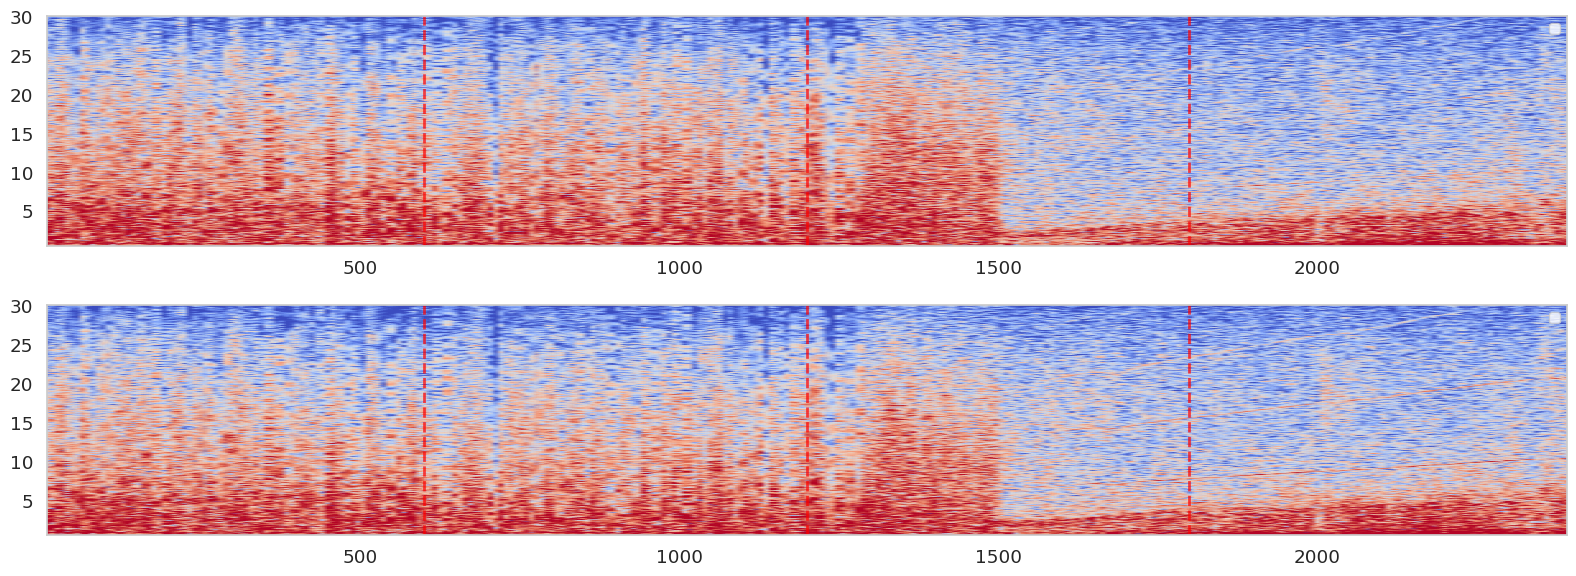

In [41]:
# 绘制时频图
fig, axes = plt.subplots(n_channels, 1, figsize=(16, 3 * n_channels))
if n_channels == 1:
    axes = [axes]

for ch_idx, ax in enumerate(axes):
    data = time_frequency_data[ch_idx]
    freqs = data['freqs']
    times = data['times']
    power_dB = data['power_dB']
    channel_name = data['channel']
    
    # 绘制时频图
    im = ax.pcolormesh(times, freqs, power_dB, 
                       shading='gouraud', 
                       cmap='coolwarm',
                       vmin=np.nanpercentile(power_dB, 5),
                       vmax=np.nanpercentile(power_dB, 95))
    
    ax.set_ylim(freq_range[0], freq_range[1])
    
    
    # 标记不同时间段的分界点
    time_boundaries = [0, 600, 1200, 1800, 2400]  # 每10分钟一个分界点
    for i, boundary in enumerate(time_boundaries[1:-1], 1):
        if boundary <= times[-1]:
            ax.axvline(x=boundary, color='red', linestyle='--', 
                      linewidth=2, alpha=0.7)
    if len(time_boundaries) > 2:
        ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()

# 保存图片
output_path_png = os.path.join(output_dir, 'time_frequency_spectrogram_dB.png')
output_path_pdf = os.path.join(output_dir, 'time_frequency_spectrogram_dB.pdf')
plt.savefig(output_path_png, dpi=300, bbox_inches='tight')
plt.savefig(output_path_pdf, format='pdf', dpi=300, bbox_inches='tight')
print(f"  - PNG: {output_path_png}")
print(f"  - PDF: {output_path_pdf}")
plt.show()


In [94]:
# 计算四个阶段的频率归一化功率（%）
# 基于时频图数据计算，确保与时频图一致

# 定义四个阶段的时间范围（秒）
segment_boundaries = {
    'anesthesia_10min': (0, 600),
    'post_anesthesia_10min': (600, 1200),
    'post_anesthesia_20min_1': (1200, 1500),
    'post_anesthesia_20min_2': (1500, 1800),
    'post_anesthesia_30min': (1800, 2400)
}

segment_names = ['anesthesia_10min', 'post_anesthesia_10min', 'post_anesthesia_20min_1', 'post_anesthesia_20min_2', 'post_anesthesia_30min']
segment_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', 'gray', '#d62728']

# 存储每个阶段的归一化功率
normalized_power_by_segment = {}

print("="*60)
print("基于时频图计算四个阶段的频率归一化功率（%）")
print("="*60)

# 使用第一个通道的时频图数据（或对两个通道平均）
# 从时频图中提取每个阶段的平均功率
for seg_idx, (seg_key, (start_time, end_time)) in enumerate(segment_boundaries.items()):
    print(f"\n处理阶段 {seg_idx+1}: {segment_names[seg_idx]} ({start_time}-{end_time}秒)")
    
    # 对每个通道处理
    segment_normalized_power_list = []
    
    for ch_idx in range(n_channels):
        # 获取该通道的时频图数据
        tf_data = time_frequency_data[ch_idx]
        freqs = tf_data['freqs']  # 频率数组
        times = tf_data['times']  # 时间数组
        power_dB = tf_data['power_dB']  # 功率（dB），形状为 (n_freqs, n_times)
        
        # 找到该阶段对应的时间索引
        time_mask = (times >= start_time) & (times <= end_time)
        
        if not time_mask.any():
            print(f"  ⚠ 警告: 阶段 {segment_names[seg_idx]} 在时频图时间范围内没有数据")
            continue
        
        # 提取该阶段的功率数据（dB）
        segment_power_dB = power_dB[:, time_mask]  # 形状: (n_freqs, n_time_points_in_segment)
        
        # 将dB转换为线性功率（μV²/Hz）
        # power = 10^(power_dB / 10)
        segment_power_linear = 10 ** (segment_power_dB / 10)
        
        # 计算该阶段在时间维度上的平均功率谱密度（对时间求平均）
        # 形状: (n_freqs,)，单位：μV²/Hz
        segment_psd_mean = np.mean(segment_power_linear, axis=1)
        
        # 使用梯形积分计算总功率（处理非均匀频率分布）
        # 总功率 = ∫ PSD(f) df，使用梯形法则
        if len(freqs) > 1:
            # 使用numpy的trapz进行梯形积分
            total_power = np.trapz(segment_psd_mean, freqs)
        else:
            # 如果只有一个频率点，使用简单的乘法
            total_power = segment_psd_mean[0] * 1.0
        
        # 避免除以0
        if total_power == 0 or np.isnan(total_power) or np.isinf(total_power):
            total_power = 1e-10
        
        # 计算归一化功率密度（百分比）
        # 标准方法：每个频率的功率贡献 / 总功率 × 100
        # 功率贡献 = PSD(f) × df，使用梯形法则计算每个频率点的权重
        if len(freqs) > 1:
            # 计算每个频率点的频率间隔（用于梯形积分）
            freq_intervals = np.zeros_like(freqs)
            freq_intervals[0] = (freqs[1] - freqs[0])  # 第一个点：使用到下一个点的间隔
            freq_intervals[-1] = (freqs[-1] - freqs[-2])  # 最后一个点：使用前一个间隔
            # 中间点：使用前后间隔的平均（梯形法则）
            freq_intervals[1:-1] = (freqs[2:] - freqs[:-2]) / 2
            
            # 每个频率点的功率贡献 = PSD × df
            power_contributions = segment_psd_mean * freq_intervals
            
            # 归一化功率 = 功率贡献 / 总功率 × 100
            normalized_power = (power_contributions / total_power) * 100
        else:
            # 单个频率点的情况
            normalized_power = np.array([100.0])
        
        # 验证：归一化功率之和应该接近100%
        total_check = np.sum(normalized_power)
        if abs(total_check - 100) > 0.1:  # 允许0.1%的误差
            print(f"    ⚠ 警告: 归一化功率总和 = {total_check:.2f}%，与100%差异: {abs(total_check - 100):.2f}%")
        
        segment_normalized_power_list.append(normalized_power)
        
        print(f"  通道 {ch_idx+1} ({ch_names[ch_idx]}): "
              f"时间点数={np.sum(time_mask)}, "
              f"频率点数={len(freqs)}, "
              f"归一化功率范围={normalized_power.min():.2f}%-{normalized_power.max():.2f}%")
    
    if len(segment_normalized_power_list) == 0:
        continue
    
    # 转换为数组：形状为 (n_channels, n_freqs)
    segment_normalized_power = np.array(segment_normalized_power_list)
    
    # 对两个通道求平均
    segment_normalized_power_mean = np.mean(segment_normalized_power, axis=0)
    
    # 保存频率数组（第一次）
    if seg_idx == 0:
        frequencies_all = freqs
    
    # 平滑采样：先采样到60个点，然后进行高斯平滑，最后降采样到30个点
    # 并在频率0处添加0值点，确保从(0, 0)开始
    n_intermediate_points = 60  # 中间采样点数
    n_target_points = 30  # 最终输出点数
    freq_min = freqs[0]
    freq_max = freqs[-1]
    
    # 第一步：插值到60个点
    from scipy.interpolate import interp1d
    from scipy.ndimage import gaussian_filter1d
    
    # 创建中间频率点（均匀分布，60个点，从freq_min开始）
    freqs_intermediate = np.linspace(freq_min, freq_max, n_intermediate_points)
    
    # 使用三次样条插值进行重采样到60个点
    # 使用fill_value=0确保在边界外不产生非零值
    interp_func = interp1d(freqs, segment_normalized_power_mean, 
                          kind='cubic', 
                          bounds_error=False, 
                          fill_value=0.0)  # 边界外填充0，而不是外推
    power_intermediate = interp_func(freqs_intermediate)
    
    # 确保第一个点的功率为0（如果频率接近0）
    if freqs_intermediate[0] < 0.1:  # 如果第一个频率点接近0
        power_intermediate[0] = 0.0
    
    # 第二步：对60个点进行高斯平滑
    # sigma参数控制平滑程度（值越大越平滑）
    # 对于60个点，sigma=1-2比较合适
    sigma = 1.5  # 高斯平滑的标准差
    power_smoothed = gaussian_filter1d(power_intermediate, sigma=sigma, mode='nearest')
    
    # 确保平滑后第一个点的功率仍然为0
    if freqs_intermediate[0] < 0.1:
        power_smoothed[0] = 0.0
    
    # 第三步：从60个平滑后的点降采样到30个点
    # 注意：第一个点应该是0，功率也应该是0
    freqs_resampled = np.linspace(0, freq_max, n_target_points)  # 从0开始
    interp_func_final = interp1d(freqs_intermediate, power_smoothed, 
                                kind='linear',  # 使用线性插值，因为已经平滑过了
                                bounds_error=False, 
                                fill_value=0.0)  # 边界外填充0
    power_resampled = interp_func_final(freqs_resampled)
    
    # 确保第一个点（频率=0）的功率为0
    power_resampled[0] = 0.0
    
    # 确保归一化功率之和仍然接近100%（重新归一化）
    # 注意：只对非零频率点（频率>0）进行归一化，确保0处的值保持为0
    non_zero_mask = freqs_resampled > 0
    if np.sum(non_zero_mask) > 0:
        # 只对非零频率点的功率进行归一化
        total_power_non_zero = np.sum(power_resampled[non_zero_mask])
        if total_power_non_zero > 0:
            power_resampled[non_zero_mask] = power_resampled[non_zero_mask] / total_power_non_zero * 100
        # 确保0处的值保持为0
        power_resampled[0] = 0.0
    
    # 保存原始和重采样后的数据
    normalized_power_by_segment[seg_key] = {
        'power': power_resampled,  # 重采样后的归一化功率（30个点）
        'power_original': segment_normalized_power_mean,  # 原始归一化功率
        'power_per_channel': segment_normalized_power,  # 每个通道的归一化功率
        'name': segment_names[seg_idx],
        'freqs': freqs_resampled,  # 重采样后的频率（30个点）
        'freqs_original': freqs  # 原始频率
    }
    
    # 验证：归一化功率之和应该接近100%
    # 注意：频率0处的值是0，其他点的总和应该是100%
    total_percent = np.sum(power_resampled)
    non_zero_total = np.sum(power_resampled[freqs_resampled > 0])
    print(f"  验证: 归一化功率总和 = {total_percent:.2f}% (频率0处={power_resampled[0]:.2f}%, "
          f"非零频率总和={non_zero_total:.2f}%)")
    print(f"  处理流程: {len(freqs)} 个点 -> {n_intermediate_points} 个点(插值) -> "
          f"{n_intermediate_points} 个点(高斯平滑, σ={sigma}) -> {n_target_points} 个点(降采样, 从0开始)")

print(f"\n{'='*60}")
print("频率归一化功率计算完成！")
print(f"{'='*60}")


基于时频图计算四个阶段的频率归一化功率（%）

处理阶段 1: anesthesia_10min (0-600秒)
  通道 1 (A-005): 时间点数=75, 频率点数=945, 归一化功率范围=0.00%-1.10%
  通道 2 (A-007): 时间点数=75, 频率点数=945, 归一化功率范围=0.00%-1.24%
  验证: 归一化功率总和 = 100.00% (频率0处=0.00%, 非零频率总和=100.00%)
  处理流程: 945 个点 -> 60 个点(插值) -> 60 个点(高斯平滑, σ=1.5) -> 30 个点(降采样, 从0开始)

处理阶段 2: post_anesthesia_10min (600-1200秒)
  通道 1 (A-005): 时间点数=76, 频率点数=945, 归一化功率范围=0.00%-1.84%
  通道 2 (A-007): 时间点数=76, 频率点数=945, 归一化功率范围=0.00%-2.09%
  验证: 归一化功率总和 = 100.00% (频率0处=0.00%, 非零频率总和=100.00%)
  处理流程: 945 个点 -> 60 个点(插值) -> 60 个点(高斯平滑, σ=1.5) -> 30 个点(降采样, 从0开始)

处理阶段 3: post_anesthesia_20min_1 (1200-1500秒)
  通道 1 (A-005): 时间点数=38, 频率点数=945, 归一化功率范围=0.00%-0.94%
    ⚠ 警告: 归一化功率总和 = 100.11%，与100%差异: 0.11%
  通道 2 (A-007): 时间点数=38, 频率点数=945, 归一化功率范围=0.00%-1.03%
  验证: 归一化功率总和 = 100.00% (频率0处=0.00%, 非零频率总和=100.00%)
  处理流程: 945 个点 -> 60 个点(插值) -> 60 个点(高斯平滑, σ=1.5) -> 30 个点(降采样, 从0开始)

处理阶段 4: post_anesthesia_20min_2 (1500-1800秒)
    ⚠ 警告: 归一化功率总和 = 101.23%，与100%差异: 1.23%
  通道 1 (A-005): 时间点数=3


频率归一化功率折线图已保存:
  - PNG: /media/ubuntu/sda/cen/EEG_results/frequency_normalized_power_lineplot.png
  - PDF: /media/ubuntu/sda/cen/EEG_results/frequency_normalized_power_lineplot.pdf


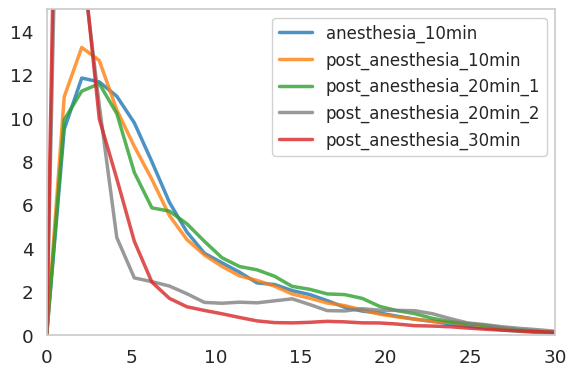

In [97]:
# 绘制四个阶段的频率归一化功率（%）折线图（30个点）
fig, ax = plt.subplots(figsize=(6, 4))

# 绘制四条线（每个阶段30个点）
for seg_idx, (seg_key, seg_data) in enumerate(normalized_power_by_segment.items()):
    power = seg_data['power']  # 重采样后的归一化功率（30个点）
    name = seg_data['name']
    freqs = seg_data['freqs']  # 重采样后的频率（30个点）
    color = segment_colors[seg_idx]
    
    ax.plot(freqs, power, 
            label=name, 
            color=color, 
            linewidth=2.5,
            alpha=0.8)  # 每个点都显示标记


# 设置x轴从0开始，确保从(0, 0)开始绘制
ax.set_xlim(0, freq_range[1])  # 从0开始，而不是从freq_range[0]开始
ax.set_ylim(0, 15)  # y轴从0开始，自动调整上限
ax.grid(True, alpha=0, linestyle='--')
ax.legend(loc='best', fontsize=12, framealpha=0.9)



plt.tight_layout()

# 保存图片
output_path_png = os.path.join(output_dir, 'frequency_normalized_power_lineplot.png')
output_path_pdf = os.path.join(output_dir, 'frequency_normalized_power_lineplot.pdf')
plt.savefig(output_path_png, dpi=300, bbox_inches='tight')
plt.savefig(output_path_pdf, format='pdf', dpi=300, bbox_inches='tight')
print(f"\n频率归一化功率折线图已保存:")
print(f"  - PNG: {output_path_png}")
print(f"  - PDF: {output_path_pdf}")
plt.show()


In [104]:
band_limits = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30)
}
band_names = ['delta', 'theta', 'alpha', 'beta']
band_colors = {'delta': '#1f77b4', 'theta': '#ff7f0e', 'alpha': '#2ca02c', 'beta': '#d62728'}
band_labels = {'delta': 'Delta (0.5-4 Hz)', 'theta': 'Theta (4-8 Hz)', 
               'alpha': 'Alpha (8-12 Hz)', 'beta': 'Beta (12-30 Hz)'}

band_traces = {}
for band in band_limits.keys():
    band_recording = spre.bandpass_filter(EEG_recording_concatenated, freq_min = band_limits[band][0], freq_max = band_limits[band][1])
    band_traces[band] = band_recording.get_traces() ** 2

In [106]:
# 对齐并降采样band_traces至480个点，然后绘制各频段的折线图
target_points = 480  # 目标采样点数

# 计算总时长（秒）
total_duration = EEG_recording_concatenated.get_total_duration()

# 创建目标时间轴（均匀分布，480个点）
time_resampled = np.linspace(0, total_duration, target_points)

# 存储降采样后的数据
band_traces_resampled = {}

print("="*60)
print(f"对齐并降采样band_traces至{target_points}个点")
print("="*60)

# 对每个频段进行处理
for band_name in band_names:
    print(f"\n处理频段: {band_name} ({band_limits[band_name][0]}-{band_limits[band_name][1]} Hz)")
    
    # 获取原始trace数据
    band_trace = band_traces[band_name]  # 形状: (n_times, n_channels)
    original_n_times = band_trace.shape[0]
    
    print(f"  原始数据形状: {band_trace.shape}")
    print(f"  原始时间点数: {original_n_times}")
    
    # 创建原始时间轴
    time_original = np.linspace(0, total_duration, original_n_times)
    
    # 对每个通道进行降采样
    band_trace_resampled = []
    for ch_idx in range(band_trace.shape[1]):
        # 使用scipy.signal.resample进行降采样
        trace_resampled = signal.resample(band_trace[:, ch_idx], target_points)
        band_trace_resampled.append(trace_resampled)
    
    # 转换为数组：形状为 (target_points, n_channels)
    band_trace_resampled = np.array(band_trace_resampled).T
    
    # 对两个通道求平均（如果需要）
    band_trace_mean = np.mean(band_trace_resampled, axis=1)  # 形状: (target_points,)
    
    band_traces_resampled[band_name] = {
        'trace': band_trace_mean,  # 平均后的trace（480个点）
        'trace_per_channel': band_trace_resampled,  # 每个通道的trace
        'time': time_resampled  # 时间轴（480个点）
    }
    
    print(f"  降采样后形状: {band_trace_resampled.shape}")
    print(f"  平均trace范围: {band_trace_mean.min():.4f} - {band_trace_mean.max():.4f}")

print(f"\n{'='*60}")
print("降采样完成！")
print(f"{'='*60}")


对齐并降采样band_traces至480个点

处理频段: delta (0.5-4 Hz)
  原始数据形状: (480000, 2)
  原始时间点数: 480000
  降采样后形状: (480, 2)
  平均trace范围: 1252.6840 - 6753.1476

处理频段: theta (4-8 Hz)
  原始数据形状: (480000, 2)
  原始时间点数: 480000
  降采样后形状: (480, 2)
  平均trace范围: 126.0140 - 5905.4409

处理频段: alpha (8-12 Hz)
  原始数据形状: (480000, 2)
  原始时间点数: 480000
  降采样后形状: (480, 2)
  平均trace范围: -364.5071 - 5841.0381

处理频段: beta (12-30 Hz)
  原始数据形状: (480000, 2)
  原始时间点数: 480000
  降采样后形状: (480, 2)
  平均trace范围: -302.4477 - 5464.0895

降采样完成！



各频段折线图已保存:
  - PNG: /media/ubuntu/sda/cen/EEG_results/band_traces_lineplot.png
  - PDF: /media/ubuntu/sda/cen/EEG_results/band_traces_lineplot.pdf


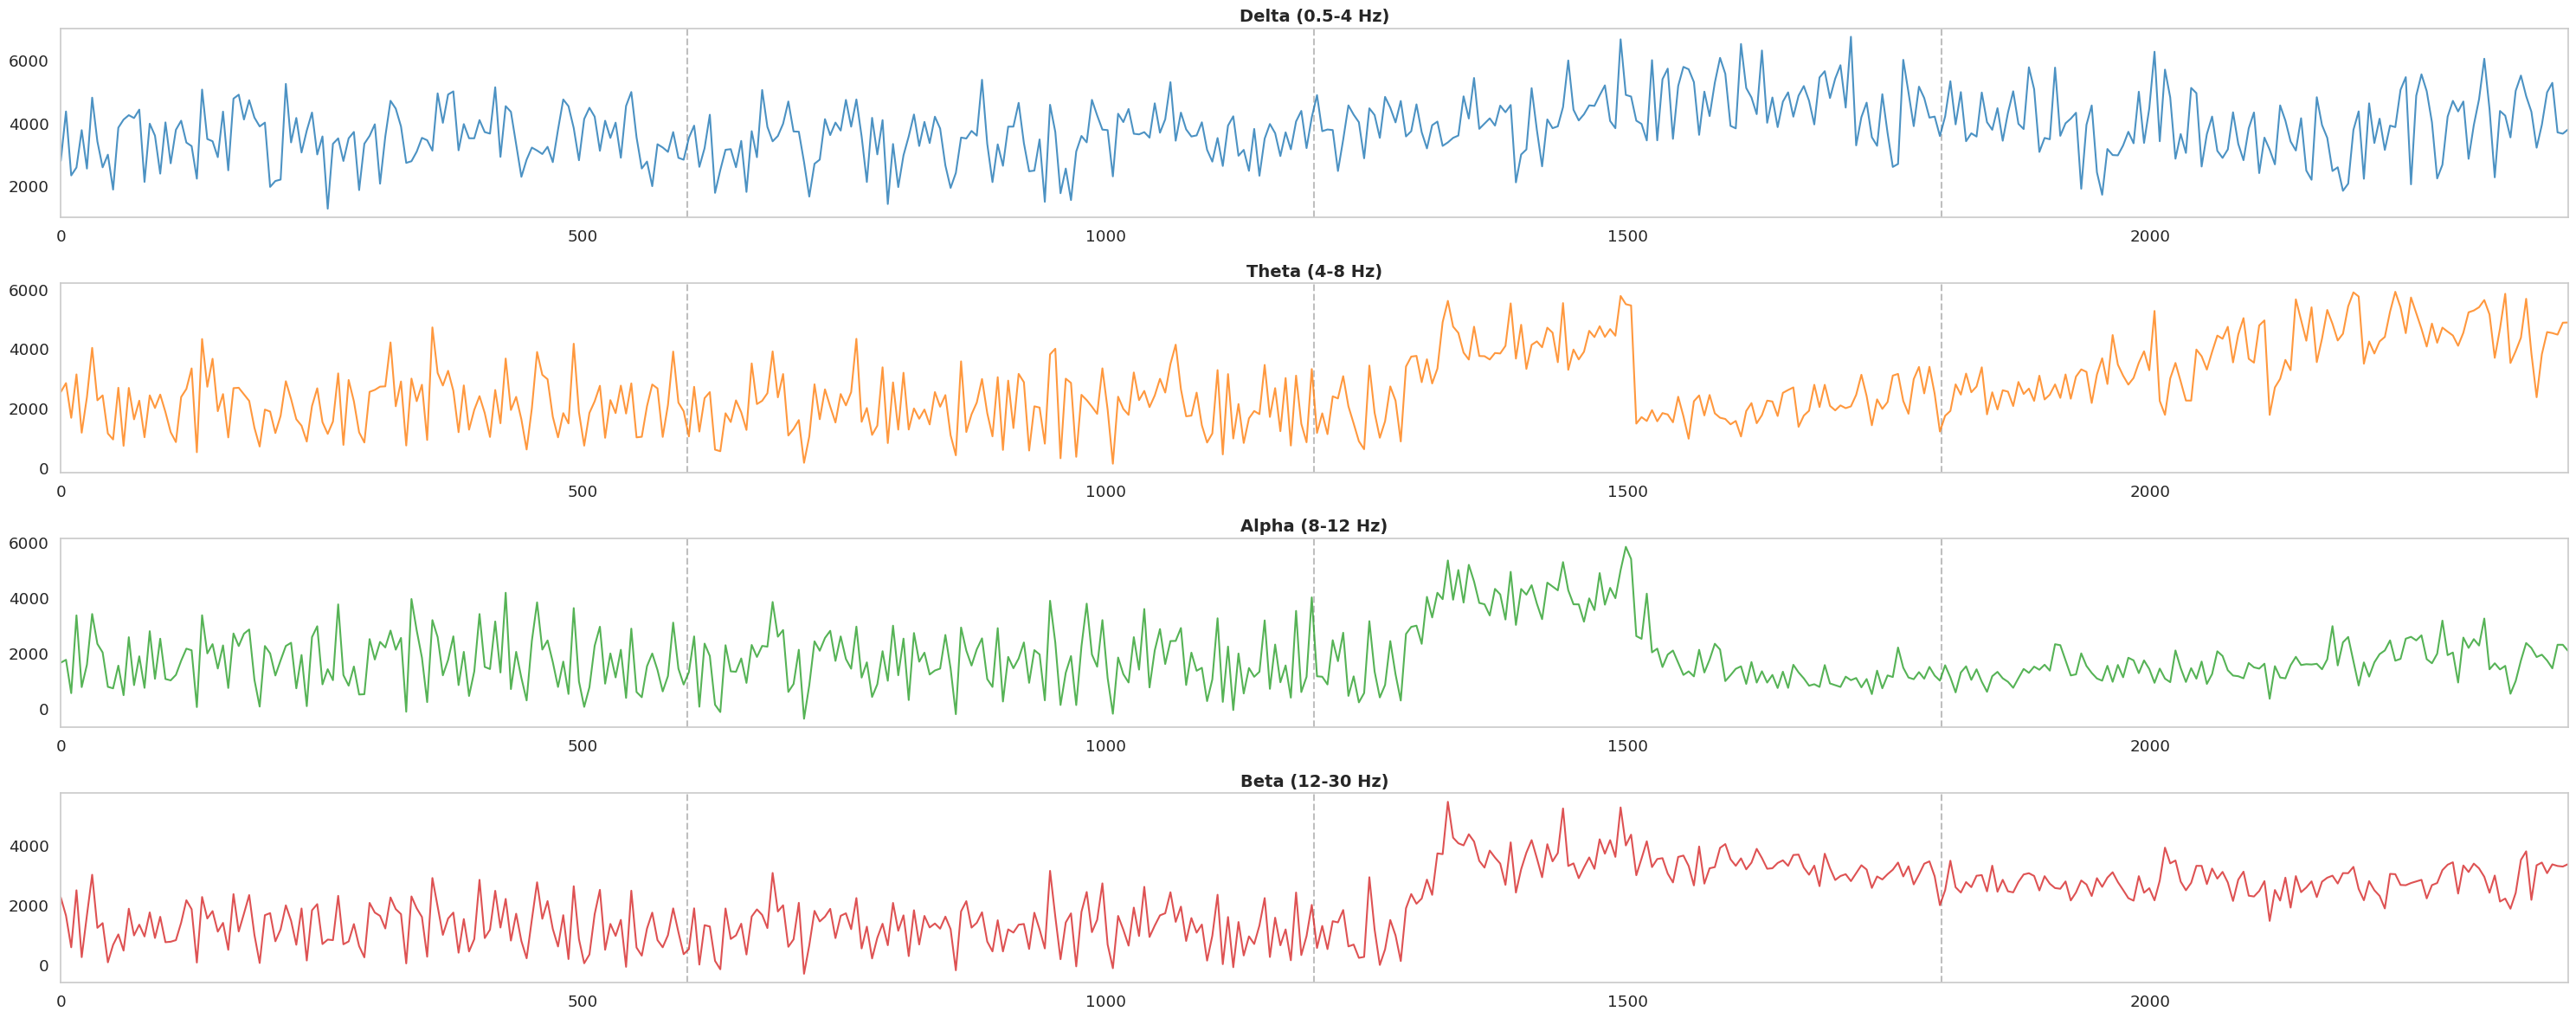

In [109]:
# 绘制各频段的折线图
fig, axes = plt.subplots(len(band_names), 1, figsize=(30, 3 * len(band_names)))
if len(band_names) == 1:
    axes = [axes]

for band_idx, band_name in enumerate(band_names):
    ax = axes[band_idx]
    
    time_data = band_traces_resampled[band_name]['time']
    trace_data = band_traces_resampled[band_name]['trace']
    
    ax.plot(time_data, trace_data, 
            color=band_colors[band_name],
            linewidth=1.5,
            alpha=0.8,
            label=band_labels[band_name])
    
    time_boundaries = [0, 600, 1200, 1800, 2400]  
    for i, boundary in enumerate(time_boundaries[1:-1], 1):
        if boundary <= time_data[-1]:
            ax.axvline(x=boundary, color='gray', linestyle='--', 
                      linewidth=1.5, alpha=0.5, zorder=0)
    
    ax.set_title(f'{band_labels[band_name]}', fontsize=14, fontweight='bold')
    ax.set_xlim(time_data[0], time_data[-1])
    ax.grid(True, alpha=0, linestyle='--', axis='both')

plt.tight_layout()

# 保存图片
output_path_png = os.path.join(output_dir, 'band_traces_lineplot.png')
output_path_pdf = os.path.join(output_dir, 'band_traces_lineplot.pdf')
plt.savefig(output_path_png, dpi=300, bbox_inches='tight')
plt.savefig(output_path_pdf, format='pdf', dpi=300, bbox_inches='tight')
print(f"\n各频段折线图已保存:")
print(f"  - PNG: {output_path_png}")
print(f"  - PDF: {output_path_pdf}")
plt.show()


In [98]:
# 设置参数
freq_min = 10  # 带通滤波下限 (Hz)
freq_max = 500   # 带通滤波上限 (Hz)
sfreq = 200     # 目标采样率 (Hz)

# 读取并预处理四段数据
recording_list = []
for name, file_info in data_files.items():
    print(f"正在处理: {name}")
    file_path = file_info['path']
    
    # 读取数据
    recording_raw = se.read_intan(file_path, stream_id='0')
    recording_raw = spre.unsigned_to_signed(recording_raw)
    
    # 滤波和预处理
    recording_raw = recording_raw.select_channels(['A-000', 'A-001', 'A-002', 'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-010', 'A-012', 'A-014'])
    recording_raw = spre.bandpass_filter(recording_raw, freq_min=freq_min, freq_max=freq_max)
    recording_raw = spre.notch_filter(recording_raw, freq=50)
    recording_recorded = spre.common_reference(recording_raw)
    
    # 选择通道并降采样
    EMG_recording = recording_recorded.select_channels(['A-001', 'A-003'])
    EMG_recording = spre.resample(EMG_recording, sfreq)
    
    recording_list.append(EMG_recording)
    print(f"  - 完成: {name}, 采样率: {EMG_recording.get_sampling_frequency()} Hz")

# 拼接四段数据
print("\n正在拼接数据...")
EMG_recording_concatenated = concatenate_recordings(recording_list)
print(f"拼接完成! 总时长: {EMG_recording_concatenated.get_total_duration():.1f} 秒")

正在处理: anesthesia_10min
  - 完成: anesthesia_10min, 采样率: 200.0 Hz
正在处理: post_anesthesia_10min
  - 完成: post_anesthesia_10min, 采样率: 200.0 Hz
正在处理: post_anesthesia_20min
  - 完成: post_anesthesia_20min, 采样率: 200.0 Hz
正在处理: post_anesthesia_30min
  - 完成: post_anesthesia_30min, 采样率: 200.0 Hz

正在拼接数据...
拼接完成! 总时长: 2400.0 秒


In [ ]:
EMG_traces = EMG_recording_concatenated.get_traces()

In [112]:
EMG_traces.shape

(480000, 2)

In [113]:
# 降采样EMG traces到48000个点
target_points_emg = 48000
EMG_traces_original = EMG_recording_concatenated.get_traces()  # 形状: (n_times, n_channels)
total_duration_emg = EMG_recording_concatenated.get_total_duration()

print(f"EMG原始数据形状: {EMG_traces_original.shape}")
print(f"降采样目标: {target_points_emg} 个点")

# 降采样每个通道
EMG_traces_resampled = []
time_emg_resampled = np.linspace(0, total_duration_emg, target_points_emg)

for ch_idx in range(EMG_traces_original.shape[1]):
    # 使用scipy.signal.resample进行降采样
    emg_resampled = signal.resample(EMG_traces_original[:, ch_idx], target_points_emg)
    EMG_traces_resampled.append(emg_resampled)
    print(f"  通道 {ch_idx}: {EMG_traces_original.shape[0]} -> {len(emg_resampled)} 个点")

EMG_traces_resampled = np.array(EMG_traces_resampled).T  # 形状: (48000, n_channels)
print(f"降采样后形状: {EMG_traces_resampled.shape}")

# 绘制降采样后的EMG traces
with PdfPages("/media/ubuntu/sda/cen/EEG_results/EMG_traces.pdf") as pdf:
    # 通道1
    plt.figure(figsize=(40, 2))
    sns.lineplot(x=time_emg_resampled, y=EMG_traces_resampled[:, 0], color='black')
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('EMG (μV)', fontsize=12)
    plt.title('EMG Trace - Channel A-001 (Resampled to 48000 points)', fontsize=14)
    plt.grid(False)
    pdf.savefig()
    plt.close()
    
    # 通道2
    plt.figure(figsize=(40, 2))
    sns.lineplot(x=time_emg_resampled, y=EMG_traces_resampled[:, 1], color='black')
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('EMG (μV)', fontsize=12)
    plt.title('EMG Trace - Channel A-003 (Resampled to 48000 points)', fontsize=14)
    plt.grid(False)
    pdf.savefig()
    plt.close()

print("EMG traces已降采样并保存为PDF")

EMG原始数据形状: (480000, 2)
降采样目标: 48000 个点
  通道 0: 480000 -> 48000 个点
  通道 1: 480000 -> 48000 个点
降采样后形状: (48000, 2)
EMG traces已降采样并保存为PDF


In [114]:
# 保存所有数据为CSV文件
print("="*60)
print("保存数据为CSV文件")
print("="*60)
output_dir = '/media/ubuntu/sda/cen/EEG_results'
# 1. 保存时频图数据（2个通道分别）
print("\n1. 保存时频图数据（2个通道）...")
for ch_idx in range(n_channels):
    tf_data = time_frequency_data[ch_idx]
    freqs = tf_data['freqs']
    times = tf_data['times']
    power_dB = tf_data['power_dB']  # 形状: (n_freqs, n_times)
    channel_name = tf_data['channel']
    
    # 创建DataFrame：行为频率，列为时间
    df_timefreq = pd.DataFrame(power_dB, index=freqs, columns=times)
    df_timefreq.index.name = 'Frequency (Hz)'
    df_timefreq.columns.name = 'Time (s)'
    
    # 保存为CSV
    csv_path = os.path.join(output_dir, f'time_frequency_power_dB_channel_{channel_name}.csv')
    df_timefreq.to_csv(csv_path)
    print(f"  ✓ 通道 {channel_name}: {csv_path} (形状: {power_dB.shape})")

# 2. 保存频率归一化功率折线图数据（30*5）
print("\n2. 保存频率归一化功率折线图数据（30个频率点 × 5个阶段）...")
# 创建DataFrame：行为频率，列为阶段
freqs_normalized = normalized_power_by_segment[list(segment_boundaries.keys())[0]]['freqs']
normalized_power_matrix = []

for seg_key in segment_boundaries.keys():
    if seg_key in normalized_power_by_segment:
        normalized_power_matrix.append(normalized_power_by_segment[seg_key]['power'])
    else:
        normalized_power_matrix.append(np.zeros(len(freqs_normalized)))

normalized_power_matrix = np.array(normalized_power_matrix).T  # 转置：行为频率，列为阶段

df_normalized = pd.DataFrame(
    normalized_power_matrix, 
    index=freqs_normalized,
    columns=[normalized_power_by_segment[k]['name'] for k in segment_boundaries.keys() if k in normalized_power_by_segment]
)
df_normalized.index.name = 'Frequency (Hz)'
df_normalized.columns.name = 'Stage'

csv_path = os.path.join(output_dir, 'frequency_normalized_power_30x5.csv')
df_normalized.to_csv(csv_path)
print(f"  ✓ 频率归一化功率: {csv_path} (形状: {normalized_power_matrix.shape})")

# 3. 保存band_traces_resampled（4个文件）
print("\n3. 保存band_traces_resampled（4个频段）...")
for band_name in band_names:
    time_data = band_traces_resampled[band_name]['time']
    trace_data = band_traces_resampled[band_name]['trace']  # 形状: (480,)
    
    # 创建DataFrame
    df_band = pd.DataFrame({
        'Time (s)': time_data,
        'Power (μV²)': trace_data
    })
    
    csv_path = os.path.join(output_dir, f'band_trace_{band_name}_resampled.csv')
    df_band.to_csv(csv_path, index=False)
    print(f"  ✓ {band_name}: {csv_path} (形状: {trace_data.shape})")

# 4. 保存EMG traces（2个文件，降采样到48000个点）
print("\n4. 保存EMG traces（2个通道，降采样到48000个点）...")
# 使用降采样后的EMG数据（已在Cell 14中计算）
EMG_ch_names = ['A-001', 'A-003']  # EMG通道名称

for ch_idx in range(EMG_traces_resampled.shape[1]):
    channel_name = EMG_ch_names[ch_idx]
    emg_trace = EMG_traces_resampled[:, ch_idx]
    
    # 创建DataFrame
    df_emg = pd.DataFrame({
        'Time (s)': time_emg_resampled,
        'EMG (μV)': emg_trace
    })
    
    csv_path = os.path.join(output_dir, f'EMG_trace_channel_{channel_name}_resampled.csv')
    df_emg.to_csv(csv_path, index=False)
    print(f"  ✓ 通道 {channel_name}: {csv_path} (形状: {emg_trace.shape}, 降采样到48000个点)")

print(f"\n{'='*60}")
print("所有CSV文件保存完成！")
print(f"{'='*60}")


保存数据为CSV文件

1. 保存时频图数据（2个通道）...
  ✓ 通道 A-005: /media/ubuntu/sda/cen/EEG_results/time_frequency_power_dB_channel_A-005.csv (形状: (945, 299))
  ✓ 通道 A-007: /media/ubuntu/sda/cen/EEG_results/time_frequency_power_dB_channel_A-007.csv (形状: (945, 299))

2. 保存频率归一化功率折线图数据（30个频率点 × 5个阶段）...
  ✓ 频率归一化功率: /media/ubuntu/sda/cen/EEG_results/frequency_normalized_power_30x5.csv (形状: (30, 5))

3. 保存band_traces_resampled（4个频段）...
  ✓ delta: /media/ubuntu/sda/cen/EEG_results/band_trace_delta_resampled.csv (形状: (480,))
  ✓ theta: /media/ubuntu/sda/cen/EEG_results/band_trace_theta_resampled.csv (形状: (480,))
  ✓ alpha: /media/ubuntu/sda/cen/EEG_results/band_trace_alpha_resampled.csv (形状: (480,))
  ✓ beta: /media/ubuntu/sda/cen/EEG_results/band_trace_beta_resampled.csv (形状: (480,))

4. 保存EMG traces（2个通道，降采样到48000个点）...
  ✓ 通道 A-001: /media/ubuntu/sda/cen/EEG_results/EMG_trace_channel_A-001_resampled.csv (形状: (48000,), 降采样到48000个点)
  ✓ 通道 A-003: /media/ubuntu/sda/cen/EEG_results/EMG_trace_channel_A-003_resam